In [1]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import yfinance as yf
import ipywidgets as widgets
from ipywidgets import interact

In [2]:
data=pd.read_csv("Tickers.csv")
data

,Tickers
0,MSFT
1,NVDA
2,INTC
3,PYPL
4,TM
5,WIT
6,VWAGY
7,MANU
8,BTM
9,PMMAF


In [3]:
ticker_file_path='Tickers.csv' # path to your csv
ticker_df=pd.read_csv(ticker_file_path)['Tickers'].tolist()

In [4]:
ticker_df

['MSFT', 'NVDA', 'INTC', 'PYPL', 'TM', 'WIT', 'VWAGY', 'MANU', 'BTM', 'PMMAF']

In [5]:
start_date=input("Enter the start date (YYYY-MM-DD):")
end_date=input("Enter the end date (YYYY-MM-DD):")

## Fetching stock data

In [6]:
def get_stock_data(ticker,start_date,end_date):
    try:
        data=yf.download(ticker,start=start_date,end=end_date)
        return data
    except:
        print("faildef downlpad")
        return None

## Fetch data for each ticker symbol

In [7]:
# Create empty lists to store data for each attribute
ticker_data={}

# Fetch data for each ticker symbol
for ticker in ticker_df:
   print("\n Fetching data for tickers:",ticker)
   stock_data=get_stock_data(ticker,start_date,end_date)
   if stock_data is not None:
      ticker_data[ticker]=stock_data


 Fetching data for tickers: MSFT


[*********************100%%**********************]  1 of 1 completed



 Fetching data for tickers: NVDA


[*********************100%%**********************]  1 of 1 completed



 Fetching data for tickers: INTC


...

[*********************100%%**********************]  1 of 1 completed



 Fetching data for tickers: BTM


[*********************100%%**********************]  1 of 1 completed



 Fetching data for tickers: PMMAF


[*********************100%%**********************]  1 of 1 completed


In [8]:
ticker_data

{'MSFT':                   Open        High         Low       Close   Adj Close  \
 Date                                                                     
 2022-01-03  335.350006  338.000000  329.779999  334.750000  328.120850   
 2022-01-04  334.829987  335.200012  326.119995  329.010010  322.494568   
 2022-01-05  325.859985  326.070007  315.980011  316.380005  310.114685   
 2022-01-06  313.149994  318.700012  311.489990  313.880005  307.664154   
 2022-01-07  314.149994  316.500000  310.089996  314.040009  307.820984   
 ...                ...         ...         ...         ...         ...   
 2024-05-08  408.170013  412.230011  406.709991  410.540009  410.540009   
 2024-05-09  410.570007  412.720001  409.100006  412.320007  412.320007   
 2024-05-10  412.940002  415.380005  411.799988  414.739990  414.739990   
 2024-05-13  418.010010  418.350006  410.820007  413.720001  413.720001   
 2024-05-14  412.019989  417.489990  411.549988  416.559998  416.559998   
 
               

In [9]:
df=pd.concat([data.assign(Ticker=ticker) for ticker, data in ticker_data.items()])
df

,Open,High,Low,Close,Adj Close,Volume,Ticker
Date,,,,,,,
2022-01-03,335.350006,338.000000,329.779999,334.750000,328.120850,28865100,MSFT
2022-01-04,334.829987,335.200012,326.119995,329.010010,322.494568,32674300,MSFT
2022-01-05,325.859985,326.070007,315.980011,316.380005,310.114685,40054300,MSFT
2022-01-06,313.149994,318.700012,311.489990,313.880005,307.664154,39646100,MSFT
2022-01-07,314.149994,316.500000,310.089996,314.040009,307.820984,32720000,MSFT
...,...,...,...,...,...,...,...
2024-05-08,47.000000,47.000000,47.000000,47.000000,47.000000,0,PMMAF
2024-05-09,47.000000,47.000000,47.000000,47.000000,47.000000,0,PMMAF
2024-05-10,55.700001,55.700001,54.383999,54.383999,54.383999,1000,PMMAF


In [10]:
# data_store=df.to_csv("Store_tickers.csv")
# data_store

## Closing Price

[*********************100%%**********************]  10 of 10 completed


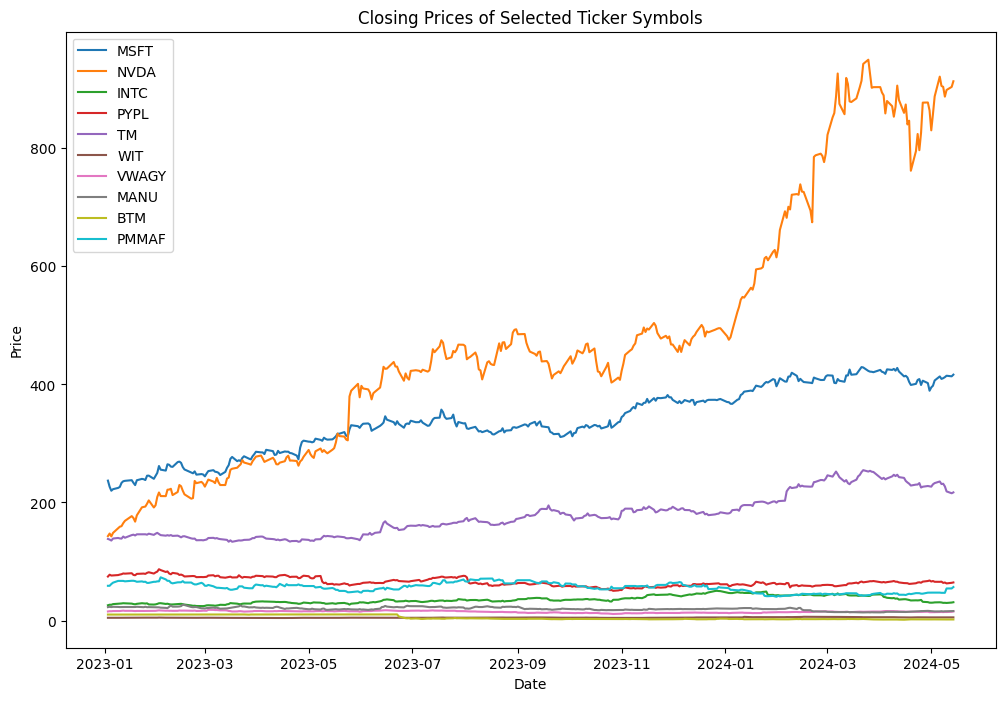

In [11]:

# List of ticker symbols
ticker_df=pd.read_csv('Tickers.csv') # path to your csv
ticker_symbols=ticker_df['Tickers'].tolist()

start_date = input("Enter the start date (YYYY-MM-DD): ")
end_date = input("Enter the end date (YYYY-MM-DD): ")

# Fetching historical data for each symbol
data = yf.download(ticker_symbols, start_date, end_date)

# Extracting closing prices
closing_prices = data['Adj Close']

# Plotting
plt.figure(figsize=(12, 8))
for symbol in ticker_symbols:
    sns.lineplot(data=closing_prices[symbol], label=symbol)

plt.title('Closing Prices of Selected Ticker Symbols')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


## Stock Comparison

[*********************100%%**********************]  2 of 2 completed


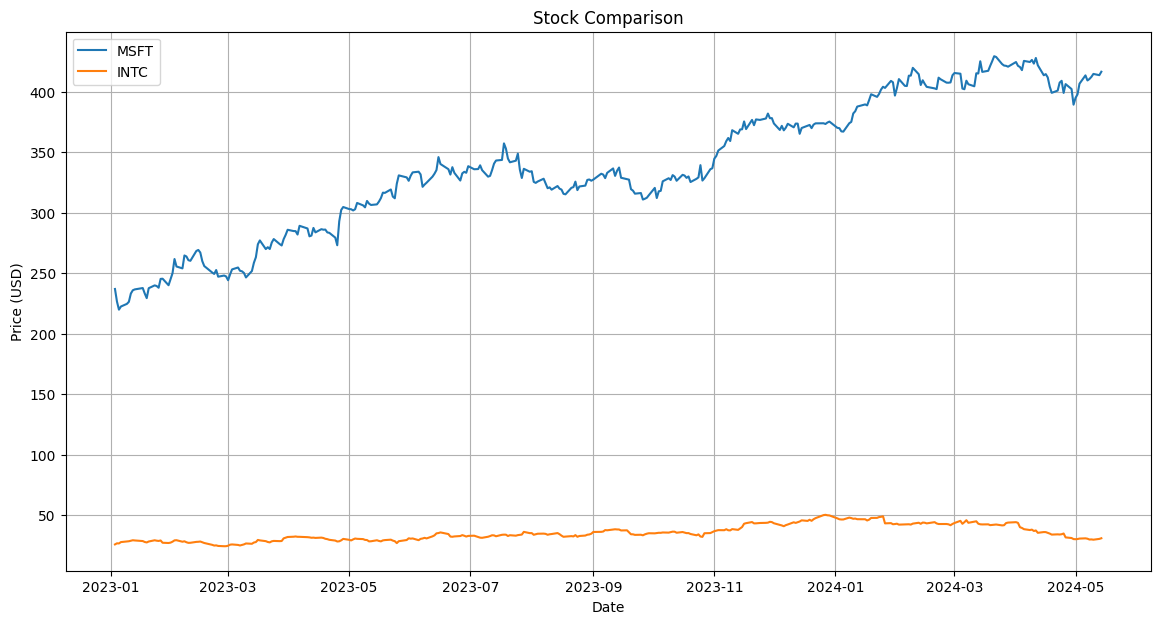

In [12]:

def plot_stock_comparison(stock1, stock2, start_date, end_date):
    # Fetching historical data for the selected stocks
    data = yf.download([stock1, stock2], start=start_date, end=end_date)["Adj Close"]

    # Plotting closing prices
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=data[stock1], label=stock1)
    sns.lineplot(data=data[stock2], label=stock2)

    plt.title('Stock Comparison')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Getting user input
stock_symbol1 = input("Enter the first stock symbol: ").upper()
stock_symbol2 = input("Enter the second stock symbol: ").upper()
start_date = input("Enter the start date (YYYY-MM-DD): ")
end_date = input("Enter the end date (YYYY-MM-DD): ")

# Plotting comparison
plot_stock_comparison(stock_symbol1, stock_symbol2, start_date, end_date)


## Standard Deviation

In [13]:
def calculate_std_dev(ticker):
    # Fetch historical data from Yahoo Finance
    stock_data = yf.download(ticker, start='2022-01-01', end='2024-03-31', progress=False)
    
    # Calculate daily returns
    stock_data['Daily_Return'] = stock_data['Close'].pct_change()
    
    # Calculate standard deviation
    std_dev = stock_data['Daily_Return'].std()
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=stock_data, x=stock_data.index, y='Close', label=f'{ticker} Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title(f'{ticker} Stock Price with Standard Deviation')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print standard deviation
    print(f'Standard Deviation ({ticker}): {std_dev:.4f}')



In [14]:
# Define stock ticker symbols
ticker_df=pd.read_csv('Tickers.csv') # path to your csv
ticker_symbols=ticker_df['Tickers'].tolist()


# Create dropdown widget
ticker_dropdown = widgets.Dropdown(options=ticker_symbols, description='Ticker Symbol:')

interact(calculate_std_dev, ticker=ticker_dropdown)


interactive(children=(Dropdown(description='Ticker Symbol:', options=('MSFT', 'NVDA', 'INTC', 'PYPL', 'TM', 'W…

<function __main__.calculate_std_dev(ticker)>

## EMA Crossover ( Exponential Moving Average )

In [15]:


# Function to get EMA crossover signals
def ema_crossover_signals(ticker, start_date, end_date):
    # Fetch historical data
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    # Calculate EMA
    data['EMA_short'] = data['Close'].ewm(span=50, adjust=False).mean()
    data['EMA_long'] = data['Close'].ewm(span=200, adjust=False).mean()
    
    # Create signals
    data['Signal'] = 0
    data.loc[data.index[1:], 'Signal'] = np.where(data['EMA_short'][1:] > data['EMA_long'][1:], 1, 0)
    data['Position'] = data['Signal'].diff()
    
    # Plot
    plt.figure(figsize=(14, 7))
    sns.lineplot(x=data.index, y=data['Close'], label='Close Price')
    sns.lineplot(x=data.index, y=data['EMA_short'], label='EMA Short')
    sns.lineplot(x=data.index, y=data['EMA_long'], label='EMA Long')
    
    # Plot Buy and Sell signals
    sns.scatterplot(x=data[data['Position'] == 1].index, y=data[data['Position'] == 1]['Close'], 
                    color='green', label='Buy', marker='^', s=100)
    sns.scatterplot(x=data[data['Position'] == -1].index, y=data[data['Position'] == -1]['Close'], 
                    color='red', label='Sell', marker='v', s=100)
    
    plt.title(f'EMA Crossover Signals for {ticker}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    

# Define ticker symbols
ticker_df=pd.read_csv('Tickers.csv') # path to your csv
ticker_symbols=ticker_df['Tickers'].tolist()

# Define start date picker
start_date_picker = widgets.DatePicker(
    description='Start Date',
    disabled=False
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    disabled=False
)

# Define interactive dropdown
ticker_dropdown = widgets.Dropdown(
    options=ticker_symbols,
    description='Ticker:',
    disabled=False,
)

# Define interactive function
def plot_signals(ticker, start_date, end_date):
    ema_crossover_signals(ticker, start_date, end_date)

# Interact function
interact(plot_signals, ticker=ticker_dropdown, start_date=start_date_picker, end_date=end_date_picker)


interactive(children=(Dropdown(description='Ticker:', options=('MSFT', 'NVDA', 'INTC', 'PYPL', 'TM', 'WIT', 'V…

<function __main__.plot_signals(ticker, start_date, end_date)>